In [8]:
import os
import cv2
import numpy as np

print("Extraction des 3 Features 'Bonus' recommandées par le jury...")

FICHIER_BONUS = "bonus_features_brutes.npy"
bonus_features = []

for nom in image_names_cnn:
    path = os.path.join(dossier_images, nom)
    
    # A. Le Minimalisme (Ratio JPEG)
    taille_octets = os.path.getsize(path)
    img_gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        raise ValueError(f"Erreur de lecture pour l'image {nom}")
        
    h, w = img_gray.shape
    ratio_compression = taille_octets / (h * w)
    
    # B. Symétrie Gauche/Droite
    grille_4x4 = cv2.resize(img_gray, (4, 4), interpolation=cv2.INTER_AREA).astype(float)
    symetrie = np.mean(np.abs(grille_4x4[:, 0] - grille_4x4[:, 3])) + \
               np.mean(np.abs(grille_4x4[:, 1] - grille_4x4[:, 2]))
    
    # C. Détection de Grilles (FFT)
    img_small = cv2.resize(img_gray, (256, 256))
    f = np.fft.fft2(img_small)
    fshift = np.fft.fftshift(f)
    magnitude = 20 * np.log(np.abs(fshift) + 1)
    
    cy, cx = 128, 128
    magnitude[cy-10:cy+10, cx-10:cx+10] = 0
    
    seuil_pics = np.mean(magnitude) + 3 * np.std(magnitude)
    nb_pics_fft = np.sum(magnitude > seuil_pics)
    
    bonus_features.append([ratio_compression, symetrie, nb_pics_fft])

# Sauvegarde sur le disque
X_bonus_brut = np.array(bonus_features)
np.save(FICHIER_BONUS, X_bonus_brut)

print(f"✅ Features Bonus extraites et sauvegardées sous '{FICHIER_BONUS}' ! Dimensions : {X_bonus_brut.shape}")

Extraction des 3 Features 'Bonus' recommandées par le jury...
✅ Features Bonus extraites et sauvegardées sous 'bonus_features_brutes.npy' ! Dimensions : (1700, 3)


In [2]:
import os
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Chargement et préparation de tous les espaces latents...")

# --- 0. Paramètres de base ---
dossier_images = "abstrait-v4" 
FICHIER_CNN = "cnn_features_pca.npy"
FICHIER_PKL_COLLEGUE = "features.pkl"
FICHIER_BONUS = "bonus_features_brutes.npy"

image_extensions = (".jpg", ".jpeg", ".png")
image_names_cnn = [f for f in os.listdir(dossier_images) if f.lower().endswith(image_extensions)]

# --- 1. Chargement du CNN (Déjà réduit) ---
if os.path.exists(FICHIER_CNN):
    X_cnn = np.load(FICHIER_CNN)
else:
    raise FileNotFoundError(f"Fichier {FICHIER_CNN} introuvable.")

# --- 2. Chargement et Traitement des features du Collègue (.pkl) ---
with open(FICHIER_PKL_COLLEGUE, "rb") as f:
    data_collegue = pickle.load(f)

# Extraction selon le format (Tuple ou DataFrame)
if isinstance(data_collegue, tuple):
    if isinstance(data_collegue[0], (list, np.ndarray)) and isinstance(data_collegue[0][0], str):
        noms_collegue = data_collegue[0]
        X_collegue_brut = np.array(data_collegue[1])
    else:
        X_collegue_brut = np.array(data_collegue[0])
        noms_collegue = data_collegue[1]
else:
    import pandas as pd
    df_collegue = pd.DataFrame(data_collegue)
    noms_collegue = df_collegue.index.tolist() if isinstance(df_collegue.index[0], str) else df_collegue.iloc[:, 0].tolist()
    X_collegue_brut = df_collegue.select_dtypes(include=[np.number]).values

dict_features_collegue = {nom: vecteur for nom, vecteur in zip(noms_collegue, X_collegue_brut)}

# Alignement
X_collegue_aligne = []
for nom in image_names_cnn:
    cles_possibles = [k for k in dict_features_collegue.keys() if nom in k]
    if cles_possibles:
        X_collegue_aligne.append(dict_features_collegue[cles_possibles[0]])
    else:
        raise ValueError(f"Image {nom} introuvable dans {FICHIER_PKL_COLLEGUE} !")
X_collegue_aligne = np.array(X_collegue_aligne)

# PCA du collègue (pour l'équilibrer avec le CNN)
n_comp = X_cnn.shape[1]
X_collegue_clean = np.nan_to_num(X_collegue_aligne, nan=np.nanmedian(X_collegue_aligne))
X_collegue_scaled = StandardScaler().fit_transform(X_collegue_clean)
X_collegue_reduit = PCA(n_components=n_comp).fit_transform(X_collegue_scaled)

# --- 3. Chargement et Traitement des Bonus ---
if os.path.exists(FICHIER_BONUS):
    X_bonus_brut = np.load(FICHIER_BONUS)
else:
    raise FileNotFoundError(f"Fichier {FICHIER_BONUS} introuvable.")

# Normalisation des bonus
X_bonus_scaled = StandardScaler().fit_transform(X_bonus_brut)

# --- 4. LA FUSION PONDÉRÉE MULTIMODALE ---
print("\nConcaténation et pondération globale de l'espace...")

# Nos réglages d'équilibrage
POIDS_CNN = 0.85
POIDS_CLASSIQUE = 0.15
POIDS_BONUS = 0.40 

# Application des poids
X_collegue_pondere = X_collegue_reduit * POIDS_CLASSIQUE
X_cnn_pondere = X_cnn * POIDS_CNN
X_bonus_final = X_bonus_scaled * POIDS_BONUS

# Assemblage final : (50) + (50) + (3) = 103 colonnes
X_final = np.hstack((X_collegue_pondere, X_cnn_pondere, X_bonus_final))

print(f"🎉 Matrice multimodale définitive prête (103 dimensions) : {X_final.shape}")

Chargement et préparation de tous les espaces latents...

Concaténation et pondération globale de l'espace...
🎉 Matrice multimodale définitive prête (103 dimensions) : (1700, 103)


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# --- 1. Lancement du K-Means sur la matrice fusionnée ---
k_choisi = 15
print(f"Lancement du clustering sur l'espace multimodal (K={k_choisi})...")
kmeans_fusion = KMeans(n_clusters=k_choisi, random_state=42, n_init=10)

# Attention : on utilise bien la variable image_names_cnn créée à l'étape d'alignement
cluster_labels = kmeans_fusion.fit_predict(X_final)

# --- 2. Évaluation Mathématique ---
score_silhouette = silhouette_score(X_final, cluster_labels)
print(f"Score de Silhouette (Fusion) : {score_silhouette:.4f}")
print("-" * 40)

# --- 3. Préparation des résultats pour l'analyse sémantique ---
artistes = [nom.split('_')[0].capitalize() for nom in image_names_cnn]
df_results = pd.DataFrame({
    'Artiste': artistes,
    'Cluster': cluster_labels
})

print("Répartition globale des œuvres par cluster :")
print(df_results['Cluster'].value_counts().sort_index())

Lancement du clustering sur l'espace multimodal (K=15)...
Score de Silhouette (Fusion) : -0.0002
----------------------------------------
Répartition globale des œuvres par cluster :
Cluster
0     222
1     164
2      54
3      63
4      79
5     150
6     121
7     147
8     183
9      98
10    107
11    131
12    100
13     15
14     66
Name: count, dtype: int64


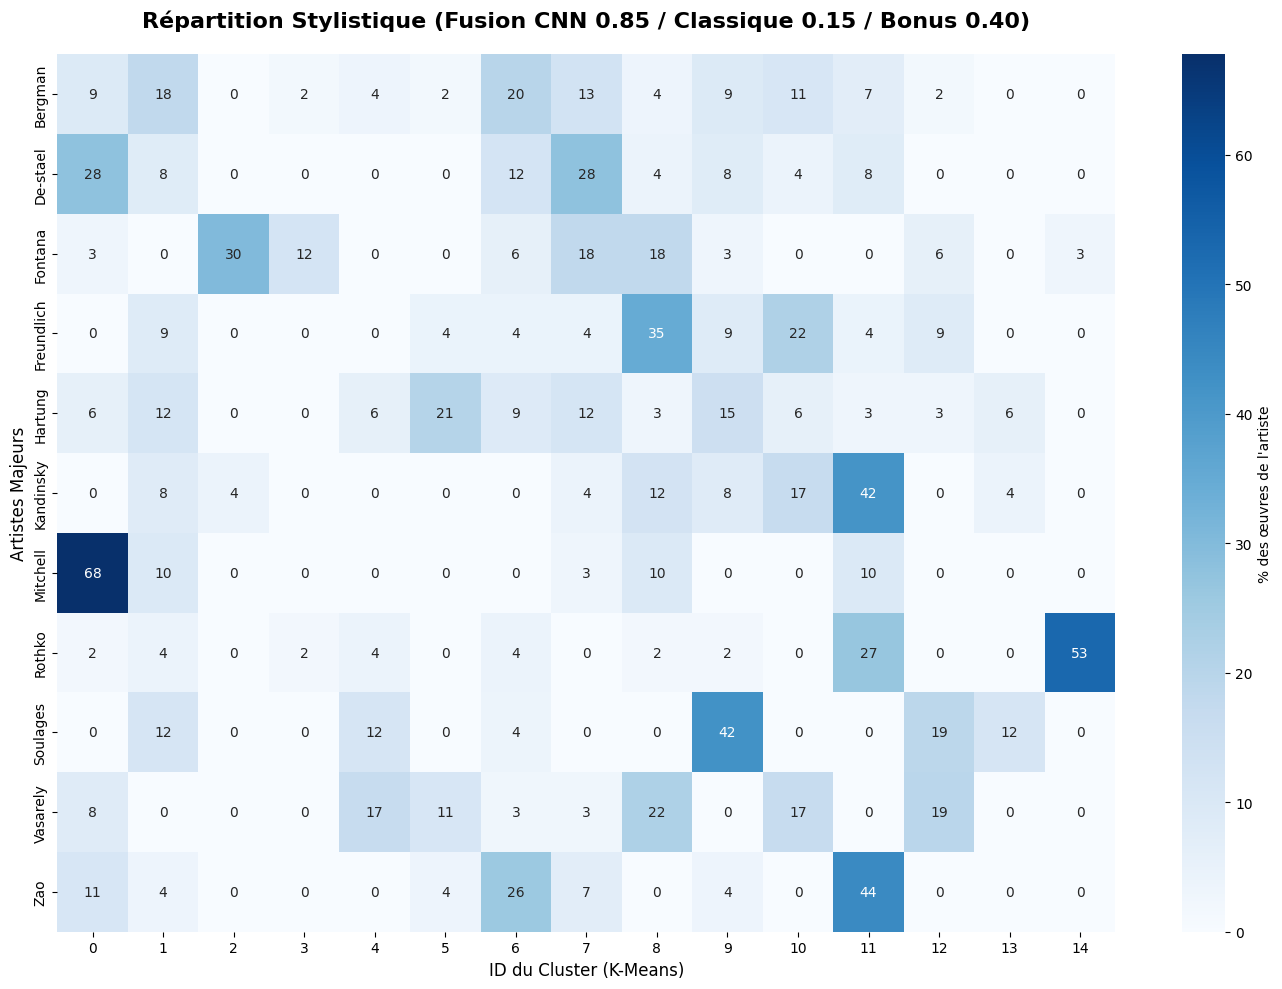

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Création du DataFrame avec la bonne liste d'images ---
artistes = [nom.split('_')[0].capitalize() for nom in image_names_cnn]
df_results = pd.DataFrame({
    'Artiste': artistes,
    'Cluster': cluster_labels
})

# --- 2. Filtrage des artistes majeurs ---
SEUIL_ARTISTES_MAJEURS = 20
comptage_artistes = df_results['Artiste'].value_counts()
artistes_majeurs = comptage_artistes[comptage_artistes >= SEUIL_ARTISTES_MAJEURS].index

df_majeurs = df_results[df_results['Artiste'].isin(artistes_majeurs)]

# --- 3. Calcul du tableau croisé en pourcentages ---
crosstab = pd.crosstab(df_majeurs['Artiste'], df_majeurs['Cluster'])
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

# --- 4. Affichage de la Heatmap ---
plt.figure(figsize=(14, 10))

sns.heatmap(crosstab_pct, annot=True, fmt=".0f", cmap="Blues", 
            cbar_kws={'label': "% des œuvres de l'artiste"})

plt.title("Répartition Stylistique (Fusion CNN 0.85 / Classique 0.15 / Bonus 0.40)", 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("ID du Cluster (K-Means)", fontsize=12)
plt.ylabel("Artistes Majeurs", fontsize=12)

plt.tight_layout()
plt.show()

Préparation de la grille des plus proches voisins (Espace Multimodal)...


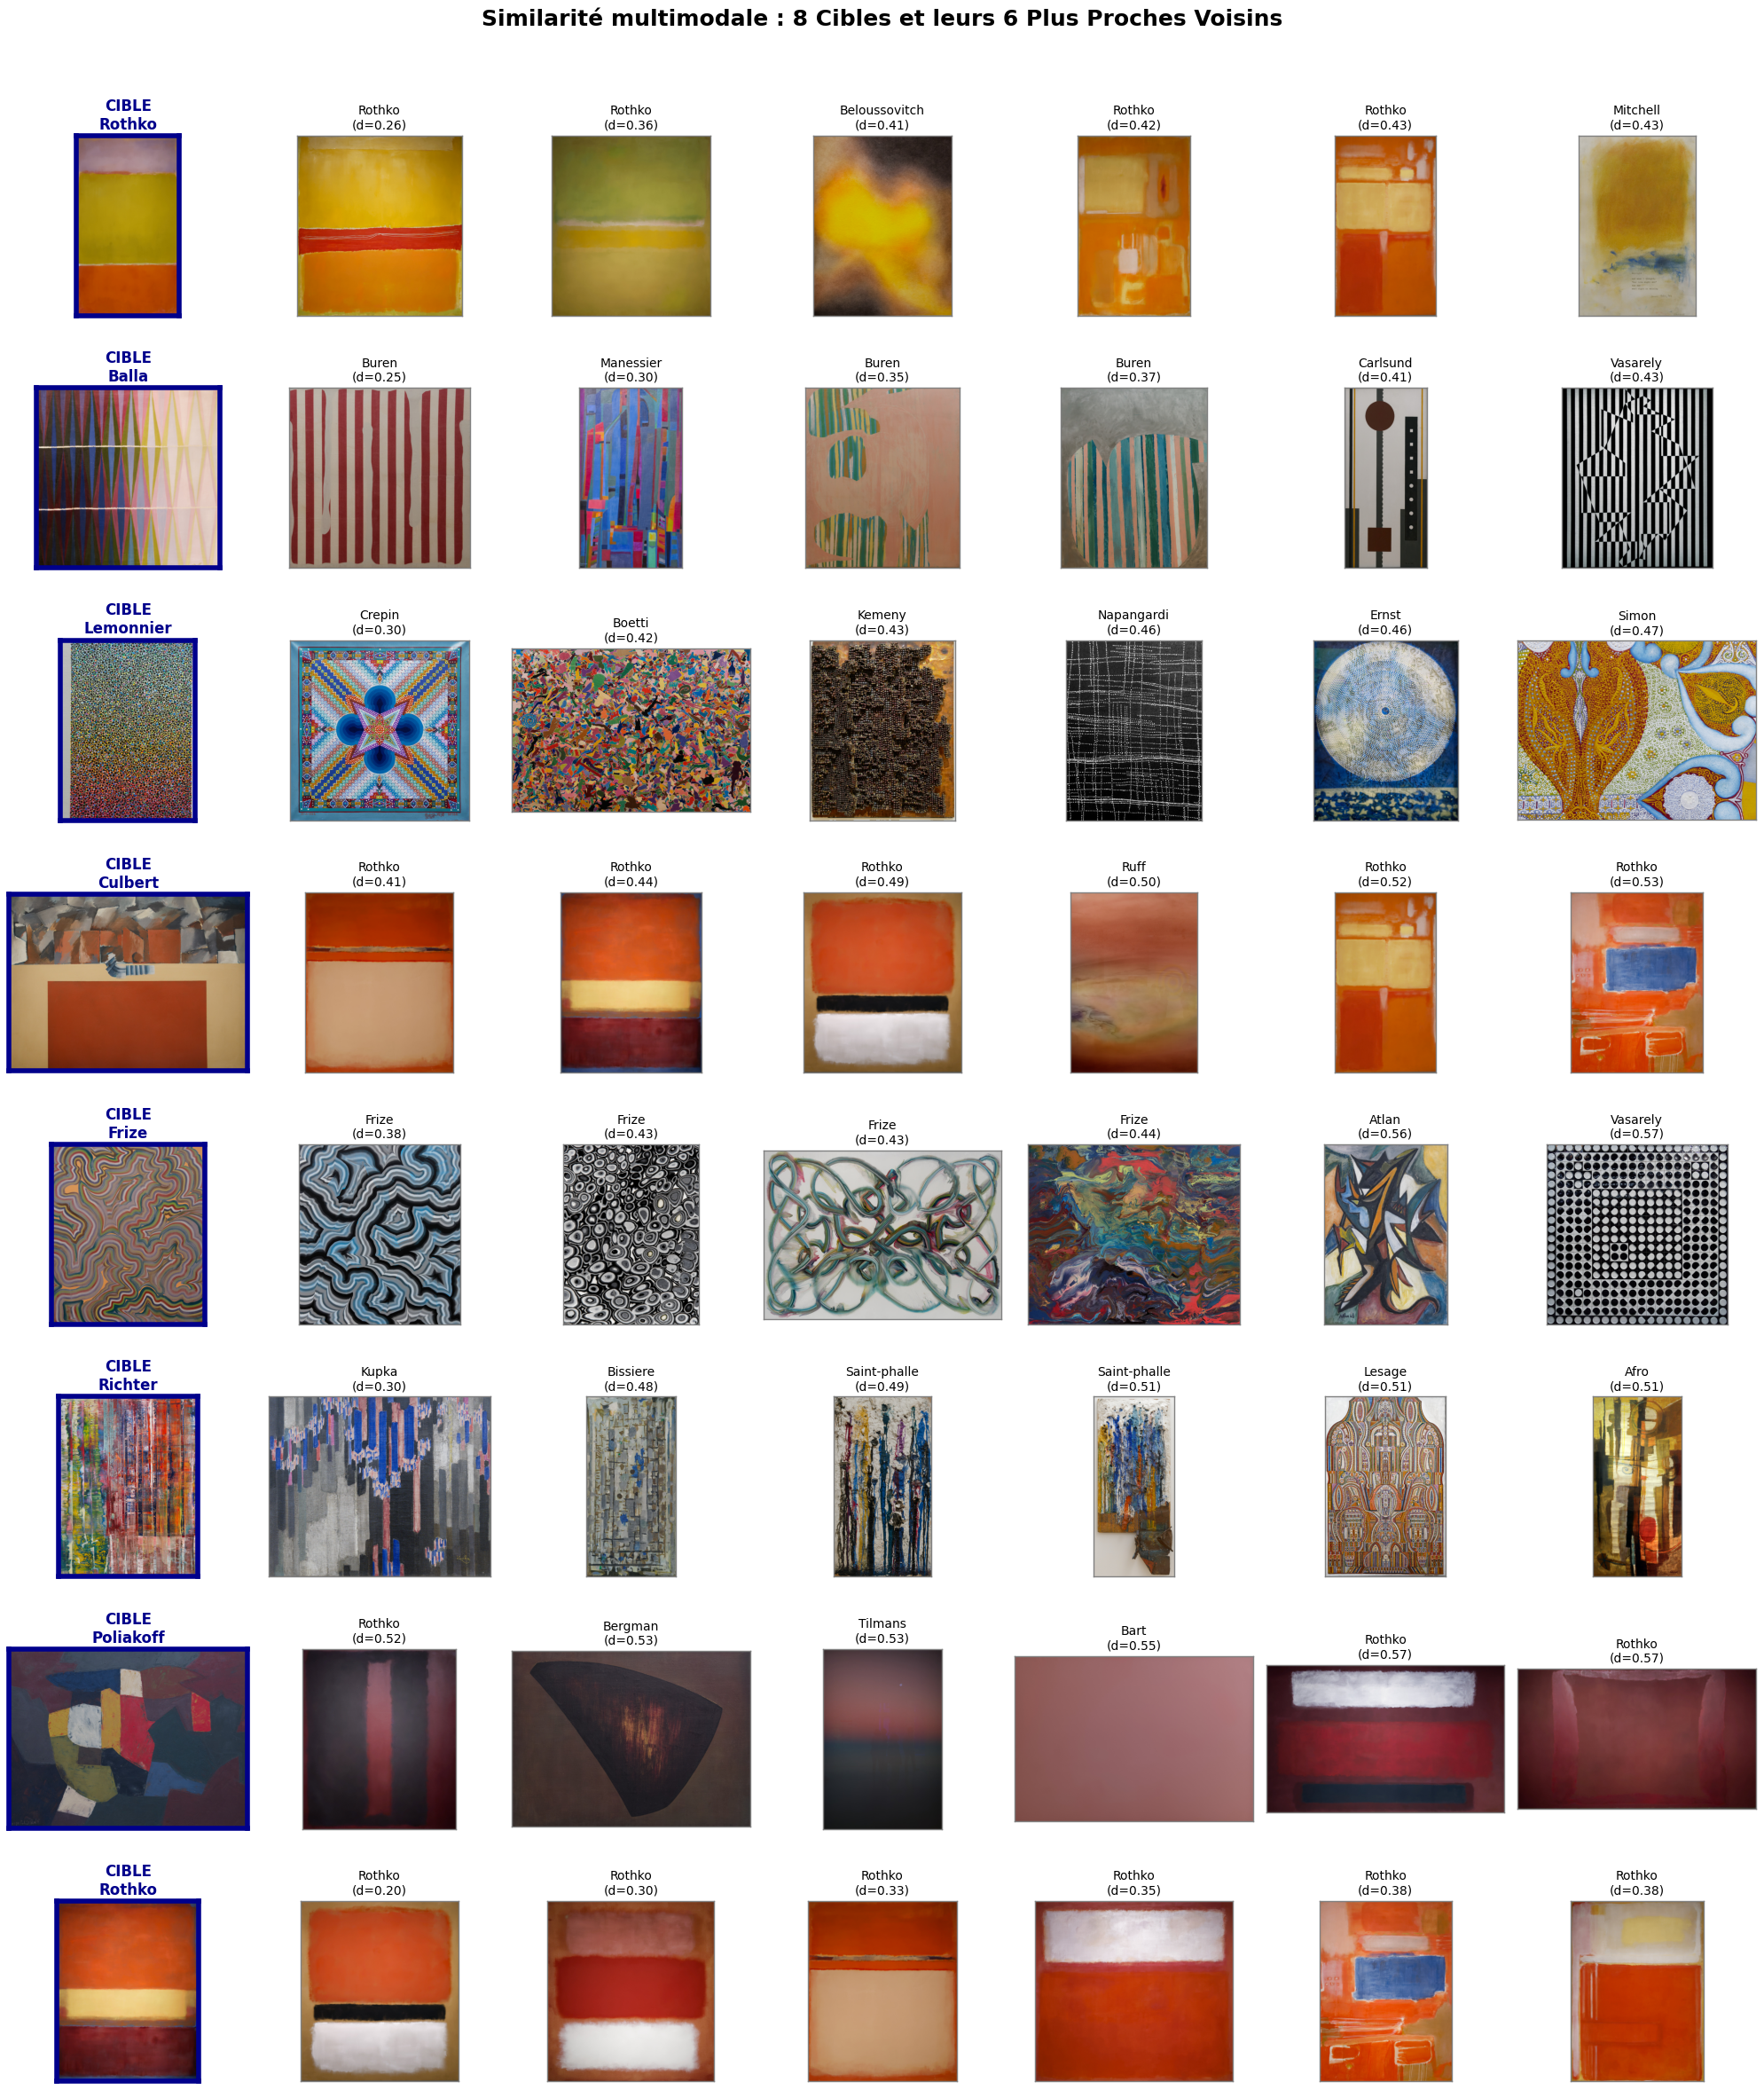

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
from sklearn.neighbors import NearestNeighbors

print("Préparation de la grille des plus proches voisins (Espace Multimodal)...")

# --- Paramètres ---
DATASET_DIR = "abstrait-v4"
NUM_TARGETS = 8     # Nombre de lignes (cibles au hasard)
N_NEIGHBORS = 6     # Nombre de voisins à trouver
N_COLS = N_NEIGHBORS + 1 

# --- 1. Entraînement du modèle de recherche sur la matrice fusionnée ---
nn_model = NearestNeighbors(n_neighbors=N_COLS, metric='cosine')
nn_model.fit(X_final)

# --- 2. Sélection aléatoire ---
random_indices = random.sample(range(len(image_names_cnn)), NUM_TARGETS)

# --- 3. Affichage ---
fig, axes = plt.subplots(NUM_TARGETS, N_COLS, figsize=(20, 3 * NUM_TARGETS))
fig.suptitle(f"Similarité multimodale : {NUM_TARGETS} Cibles et leurs {N_NEIGHBORS} Plus Proches Voisins", 
             fontsize=18, fontweight='bold', y=0.98)

for row, idx in enumerate(random_indices):
    target_vector = X_final[idx].reshape(1, -1)
    distances, indices = nn_model.kneighbors(target_vector)
    
    for col in range(N_COLS):
        ax = axes[row, col]
        voisin_idx = indices[0][col]
        voisin_name = image_names_cnn[voisin_idx]
        voisin_artiste = voisin_name.split('_')[0].capitalize()
        img_path = os.path.join(DATASET_DIR, voisin_name)
        
        try:
            img = mpimg.imread(img_path)
            ax.imshow(img)
            
            # Mise en forme : Cible (Bleu) vs Voisins (Gris)
            if col == 0:
                ax.set_title(f"CIBLE\n{voisin_artiste}", color='darkblue', fontweight='bold', fontsize=12)
                for spine in ax.spines.values():
                    spine.set_color('darkblue')
                    spine.set_linewidth(4)
            else:
                dist = distances[0][col]
                ax.set_title(f"{voisin_artiste}\n(d={dist:.2f})", fontsize=10)
                for spine in ax.spines.values():
                    spine.set_color('gray')
                    spine.set_linewidth(1)
                    
        except FileNotFoundError:
            ax.set_title("Image absente", fontsize=9)
            
        # On masque les axes
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.4) 
plt.show()

Analyse des similarités ciblées (Demande du Jury)...
✔️ Accardi : 2 œuvres trouvées.
✔️ Riley : 2 œuvres trouvées.
✔️ Vasarely : 36 œuvres trouvées.
✔️ Hantai : 7 œuvres trouvées.
✔️ Toroni : 3 œuvres trouvées.
✔️ Klee : 11 œuvres trouvées.


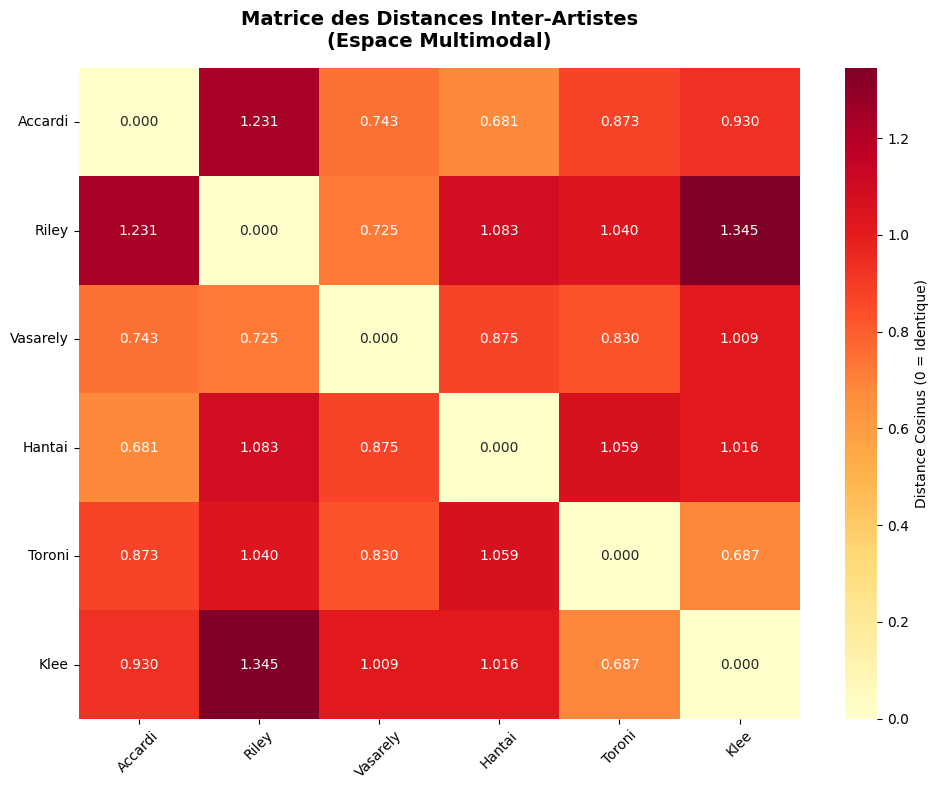

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances

print("Analyse des similarités ciblées (Demande du Jury)...")

# 1. Définition des artistes ciblés par le professeur
artistes_jury = ['Accardi', 'Riley', 'Vasarely', 'Hantai', 'Toroni', 'Klee']

# Extraction des noms d'artistes pour chaque image
noms_extraits = np.array([nom.split('_')[0].capitalize() for nom in image_names_cnn])

# 2. Calcul du Centroïde (vecteur moyen) pour chaque artiste présent
centroides = {}
for artiste in artistes_jury:
    # On cherche les index des œuvres de cet artiste
    indices = np.where(noms_extraits == artiste)[0]
    
    if len(indices) > 0:
        # On calcule la moyenne de toutes ses œuvres dans l'espace à 103 dimensions
        vecteur_moyen = np.mean(X_final[indices], axis=0)
        centroides[artiste] = vecteur_moyen
        print(f"✔️ {artiste} : {len(indices)} œuvres trouvées.")
    else:
        print(f"❌ {artiste} : Absent de la base de données actuelle.")

# 3. Création de la matrice de distance Cosinus
artistes_trouves = list(centroides.keys())
matrice_centroides = np.array(list(centroides.values()))

# Calcul des distances (Plus c'est proche de 0, plus les styles se ressemblent)
# Plus c'est proche de 1 (ou plus), plus les styles sont opposés
distances = cosine_distances(matrice_centroides)

# 4. Affichage visuel (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(distances, xticklabels=artistes_trouves, yticklabels=artistes_trouves, 
            annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={'label': 'Distance Cosinus (0 = Identique)'})

plt.title("Matrice des Distances Inter-Artistes\n(Espace Multimodal)", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
import json
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_distances

print("Lancement du clustering et analyse des résultats complets...")

# --- 1. Lancement du K-Means Final (sur X_final à 103 dimensions) ---
k_choisi = 15
kmeans_final = KMeans(n_clusters=k_choisi, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_final)
score_silhouette = silhouette_score(X_final, cluster_labels)

# --- 2. Création du DataFrame des résultats ---
artistes = [nom.split('_')[0].capitalize() for nom in image_names_cnn]
df_results = pd.DataFrame({'Artiste': artistes, 'Cluster': cluster_labels})

cluster_counts = df_results['Cluster'].value_counts().sort_index().to_dict()
cluster_balance = {f"Cluster_{k}": int(v) for k, v in cluster_counts.items()}

# --- 3. Distances Ciblées (Questions du Jury) ---
artistes_jury = ['Accardi', 'Riley', 'Vasarely', 'Hantai', 'Toroni', 'Klee']
centroides = {}
noms_extraits = np.array(artistes)

for artiste in artistes_jury:
    indices = np.where(noms_extraits == artiste)[0]
    if len(indices) > 0:
        centroides[artiste] = np.mean(X_final[indices], axis=0)

distances_dict = {}
if len(centroides) > 1:
    noms_trouves = list(centroides.keys())
    matrice_centroides = np.array(list(centroides.values()))
    dist_matrix = cosine_distances(matrice_centroides)
    
    # Formatage de la matrice pour le JSON
    for i, art_A in enumerate(noms_trouves):
        distances_dict[art_A] = {}
        for j, art_B in enumerate(noms_trouves):
            distances_dict[art_A][art_B] = round(float(dist_matrix[i, j]), 4)

# --- 4. Répartition des Artistes (Artistes Majeurs + Artistes Jury) ---
comptage = df_results['Artiste'].value_counts()
# On garde les artistes ayant plus de 20 oeuvres ET ceux demandés par le jury
artistes_a_garder = set(comptage[comptage >= 20].index.tolist() + artistes_jury)
df_majeurs = df_results[df_results['Artiste'].isin(artistes_a_garder)]

crosstab_artistes = pd.crosstab(df_majeurs['Artiste'], df_majeurs['Cluster'])
repartition_artistes = crosstab_artistes.to_dict(orient='index')
repartition_propre = {
    artiste: {str(k): int(v) for k, v in distribution.items()} 
    for artiste, distribution in repartition_artistes.items()
}

# --- 5. Création du Rapport JSON Final ---
rapport_final = {
    "1_Configuration": {
        "Dimensions_Espace": int(X_final.shape[1]),
        "Nombre_de_Clusters_K": int(k_choisi),
        "Score_de_Silhouette": round(float(score_silhouette), 4)
    },
    "2_Equilibre_des_Clusters": cluster_balance,
    "3_Distances_Jury": distances_dict,
    "4_Repartition_Artistes_Cles": repartition_propre
}

# --- 6. Affichage ---
print("\n" + "="*80)
print("📋 COPIEZ-COLLEZ LE TEXTE CI-DESSOUS DANS NOTRE DISCUSSION")
print("="*80)
print(json.dumps(rapport_final, indent=4))
print("="*80 + "\n")

Lancement du clustering et analyse des résultats complets...

📋 COPIEZ-COLLEZ LE TEXTE CI-DESSOUS DANS NOTRE DISCUSSION
{
    "1_Configuration": {
        "Dimensions_Espace": 103,
        "Nombre_de_Clusters_K": 15,
        "Score_de_Silhouette": -0.0002
    },
    "2_Equilibre_des_Clusters": {
        "Cluster_0": 222,
        "Cluster_1": 164,
        "Cluster_2": 54,
        "Cluster_3": 63,
        "Cluster_4": 79,
        "Cluster_5": 150,
        "Cluster_6": 121,
        "Cluster_7": 147,
        "Cluster_8": 183,
        "Cluster_9": 98,
        "Cluster_10": 107,
        "Cluster_11": 131,
        "Cluster_12": 100,
        "Cluster_13": 15,
        "Cluster_14": 66
    },
    "3_Distances_Jury": {
        "Accardi": {
            "Accardi": 0.0,
            "Riley": 1.2308,
            "Vasarely": 0.7426,
            "Hantai": 0.6814,
            "Toroni": 0.8729,
            "Klee": 0.9302
        },
        "Riley": {
            "Accardi": 1.2308,
            "Riley": 0.0